# **Monte Carlo Simulations Final Code**

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
from datetime import datetime
from scipy.interpolate import interp1d
from joblib import Parallel, delayed
from scipy.interpolate import PchipInterpolator

Global Mars Parameters

In [ ]:
mars_mu = 4.2828e13
mars_radius = 3396000.0

Nominal Vehicle Parameters

In [ ]:
mass_nom = 10000
gamma_nom_deg = -10.7
velocity_nom = 16000

Thermal Functions

In [ ]:
# Radiative heat flux correlation for Mars

# Below 6km/s model
def mars_slow(V, rho, Rn):
    """
    Low-speed Mars radiative heating correlation (Eq. 7)
    ---------

    Parameters
    V : Freestream velocity [km/s]
    rho : Freestream density [kg/m^3]
    Rn : Effective nose radius [m]

    Returns
    q_rad : Radiative heat flux [W/cm^2]

    """
    L = np.log(rho)

    f = (
        # Constant + first order
        -6.0539
        + 4.6540*V
        - 0.3880*L
        + 0.2274*Rn

        # Second order
        - 0.3080*V**2
        - 0.1430*V*L
        - 0.0914*V*Rn
        - 0.1584*L**2
        - 0.0856*L*Rn
        - 0.0573*Rn**2

        # Third order
        - 0.1212*V**3
        + 0.0935*V**2*L
        + 0.0371*V**2*Rn
        + 5.7929e-3*V*L**2
        - 7.4995e-4*V*Rn**2
        + 3.9562e-4*V*L*Rn
        - 9.3175e-3*L**3
        - 2.8918e-3*L**2*Rn
        + 4.0269e-3*L*Rn**2
        + 4.3082e-3*Rn**3

        # Fourth order
        + 0.0164*V**4
        - 6.6590e-3*V**3*L
        - 2.8111e-3*V**3*Rn
        + 1.0757e-3*V**2*L**2
        + 1.4478e-3*V**2*L*Rn
        + 2.9279e-4*V**2*Rn**2
        - 7.0553e-4*V*L**3
        - 2.0861e-4*V*Rn**3
        - 6.7496e-4*V*L**2*Rn
        - 7.5224e-4*V*L*Rn**2
        - 5.2606e-4*L**4
        - 3.4735e-4*L**3*Rn
        - 1.3343e-4*L**2*Rn**2
        - 8.5005e-5*L*Rn**3
        - 8.5250e-5*Rn**4
    )

    q_rad = np.exp(f)
    return q_rad

# f(v) values for Eath and Mars based on empirical data for radiative heat flux as a function of velocity

# Earth
v_earth = np.array([9000, 9250, 9500, 9750,
    10000, 10250, 10500, 10750,
    11000, 11500, 12000, 12500,
    13000, 13500, 14000, 14500,
    15000, 15500, 16000])

f_earth = np.array([1.5, 4.3, 9.7, 19.5,
    35, 55, 81, 115,
    151, 238, 359, 495,
    660, 850, 1065, 1313,
    1550, 1780, 2040])

# Mars
v_mars = np.array([6000, 6150, 6300, 6500,
    6700, 6900, 7000, 7200,
    7400, 7600, 7800, 8000,
    8200, 8400, 8600, 8800,
    9000])

f_mars =np.array([0.2, 1.0, 1.95, 3.42,
    5.1, 7.1, 8.1, 10.2,
    12.5, 14.8, 17.1, 19.2,
    21.4, 24.1, 26.0, 28.9,
    32.8])

# Interpolation for f(v) values

f_interp = interp1d(v_earth, f_earth, kind='linear')
f_interp_mars = interp1d(v_mars, f_mars, kind='linear')

# Between 6km/s and 9km/s model

def mars_medium(V, rho, Rn):

    V_table = np.clip(V*1000, v_mars[0], v_mars[-1])
    fmars = f_interp_mars(V_table)
    alpha = 2.35e4
    q_rad = alpha * (Rn ** 0.526) * (rho ** 1.19) * fmars
    return q_rad

# Above 9km/s model

def earth_fast(V, rho, Rn):

    """
    Fast-speed Earth radiative heating relation (Equivalent to Mars at that speed)

    --------------

    Parameters
    V : Freestream velocity [km/s]
    rho : Atmospheric density [kg/m^3]
    Rn : Effective nose radius [m]

    Returns
    q_rad : Radiative heat flux [W/cm^2]
    """

    V_table = np.clip(V*1000, v_earth[0], v_earth[-1])
    fE = f_interp(V_table)
    alpha = 4.72e4
    q_rad = alpha * (Rn ** 0.47) * (rho ** 1.22) * fE
    return q_rad

# ----- CONVECTIVE -----


def convective_heat_flux(V, rho, Rn):
    """
    Convective heat flux correlation

    --------------

    Parameters
    V : Freestream velocity [km/s]
    rho : Atmospheric density [kg/m^3]
    Rn : Effective nose radius [m]

    Returns
    q_conv : Convective heat flux [W/cm^2]
    """
    q_conv = 18.3 * np.sqrt(rho / Rn) * (V ** 3)
    return q_conv

Atmosphere Function

In [ ]:
def density_nom(altitude):
    """
    Calculates the atmospheric density at a given altitude above Mars.

    Parameters
    ----------
    altitude : float
        Altitude above the Martian surface in meters.

    Returns
    -------
    float
        Atmospheric density in kg/m³.
    """

    if altitude >= 130000:
        return 0.0

    elif altitude >= 40000:

        return (3.7e-4 * np.exp(-1.371e-4 * (altitude - 40000)))

    elif altitude >= 20000:

        return (2.8e-3 * np.exp(-1.012e-4 * (altitude - 20000)))

    elif altitude >= 0:

        return (1.417e-2 * np.exp(-0.8109e-4 * altitude))

    else:
        # Below the surface.
        # Prevents None from ever being returned.
        return 0

Interpolating the Density Function

In [ ]:
def density_multiplier_func():
    """
    Generates a randomized atmospheric density uncertainty profile.

    A set of altitude-dependent uncertainty values is generated by sampling
    density multipliers from normal distributions. The uncertainty standard
    deviation varies with altitude (taken from a paper by Athul Pradeepkumar 
    Girija) to represent increasing atmospheric model uncertainty at higher 
    altitudes. The sampled multipliers are then interpolated using a Piecewise 
    Cubic Hermite Interpolating Polynomial (PCHIP) to provide a continuous 
    density correction factor throughout the trajectory.

    Returns
    -------
    PchipInterpolator
        Interpolation function that returns the atmospheric density multiplier
        at a given altitude.
        
        The multiplier is applied to the nominal atmospheric density model:
        
            density = nominal_density * density_multiplier

        Values greater than 1 represent a denser-than-nominal atmosphere,
        while values less than 1 represent a less dense atmosphere.
    """

    # Altitude locations where atmospheric uncertainty is defined (m).
    altitude_points = np.array([0, 20000, 40000, 60000, 80000, 100000, 120000])

    # Standard deviation of atmospheric density uncertainty at each altitude.
    sigma_points = np.array([0.625, 0.10, 0.167, 0.28, 0.50, 0.90, 1.20])

    # Generate random density multipliers with mean value of 1.0.
    # This represents deviations from the nominal atmosphere.
    density_multipliers = np.random.normal(1.0, sigma_points)

    # Prevent unrealistically low atmospheric densities.
    density_multipliers = np.clip(density_multipliers, 0.05, None)

    # Create continuous altitude-dependent uncertainty profile.
    density_multiplier_interp = PchipInterpolator(altitude_points, density_multipliers)

    return density_multiplier_interp

Aerocapture Function

In [ ]:
def run_aerocapture(gamma_deg_monte, mass_monte, velocity_monte, lift_multiplier_monte, drag_multiplier_monte, density_multiplier):
    """
    Runs one complete Monte Carlo aerocapture simulation.

    The vehicle trajectory is propagated through three guidance phases:
    entry targeting, glide control, and atmospheric exit targeting.
    Randomized vehicle and atmospheric parameters are used to evaluate
    trajectory robustness.

    Returns a dictionary containing success status, performance metrics,
    and trajectory history.
    """

    # Initial parameters
    vehicle_ballistic_coefficient = 40.0
    vehicle_lift_to_drag = 1.0
    vehicle_nose_radius = 3.5
    initial_gamma = np.radians(gamma_deg_monte)
    vehicle_mass = mass_monte
    initial_velocity = velocity_monte
    initial_altitude = 130000.0
    initial_state = np.array([
        initial_altitude,
        0.0,
        initial_velocity,
        initial_gamma,
        0.0
    ])

    def failure_return(reason):
        """
        Creates a standardized output dictionary for failed trajectories.
        """

        return {
            "gamma_initial": gamma_deg_monte,
            "mass": vehicle_mass,
            "velocity_initial": initial_velocity,
            "lift_multiplier": lift_multiplier_monte,
            "drag_multiplier": drag_multiplier_monte,
            "density_multiplier": density_multiplier,
            "success": False,
            "failure": reason
        }


    def spacecraft_dynamics(time, state, bank_angle):
        """
        Computes Mars aerocapture equations of motion.

        State vector:
        [altitude, downrange, velocity, flight path angle, longitude angle]
        """

        altitude = state[0]
        downrange = state[1]
        velocity = state[2]
        gamma = state[3]
        theta = state[4]

        density_monte = density_nom(altitude) * density_multiplier(altitude)

        radius = mars_radius + altitude

        gravity = mars_mu / radius**2

        drag_force = (drag_multiplier_monte * 0.5 * density_monte * velocity**2 * vehicle_mass / vehicle_ballistic_coefficient)

        lift_force = lift_multiplier_monte * drag_force * vehicle_lift_to_drag

        altitude_rate = velocity * np.sin(gamma)

        downrange_rate = (mars_radius / radius) * velocity * np.cos(gamma)

        velocity_rate = (-drag_force / vehicle_mass - gravity * np.sin(gamma))

        gamma_rate = ((lift_force * np.cos(bank_angle)) / (vehicle_mass * velocity) + ((velocity**2 / radius) - gravity) * np.cos(gamma) / velocity)

        theta_rate = (velocity * np.cos(gamma) / radius)

        return [
            altitude_rate,
            downrange_rate,
            velocity_rate,
            gamma_rate,
            theta_rate
        ]


    # Create History Arrays
    trajectory_history = []
    trajectory_time_history = []
    trajectory_bank_history = []

    simulation_time = 0.0

    # ========================================================
    # STEP 1 CONTROL
    # ========================================================

    print("\n========== STARTING STEP 1 ENTRY PHASE ==========")

    #Step 1 Parameters

    STEP1_TARGET_ALTITUDE = 60000.0
    STEP1_ALTITUDE_TOLERANCE = 1000.0

    STEP1_BANK_MIN = 0.0
    STEP1_BANK_MAX = 180.0
    STEP1_NUMBER_OF_BANKS = 37

    STEP1_MAX_BANK_RATE = np.radians(10.0)
    STEP1_GUIDANCE_TIMESTEP = 2.0


    # Step 1 Event
    # Detect descending crossing of target altitude

    def step1_altitude_event(time, state, bank_angle):
        return state[0] - STEP1_TARGET_ALTITUDE

    step1_altitude_event.direction = -1
    step1_altitude_event.terminal = True


    # Predict to 60 km (defined target altitude)

    def step1_predict_to_target(state_initial, bank_angle):

        prediction_solution = solve_ivp(
            spacecraft_dynamics,
            [0.0, 2000.0],
            state_initial,
            args=(bank_angle,),
            events=step1_altitude_event,
            max_step=2.0,
            rtol=1e-8,
            atol=1e-8
        )

        if len(prediction_solution.t_events[0]) == 0:
            return None

        return prediction_solution.y_events[0][0]
    

    # Find Best Bank Angle
    # Test candidate bank angles and select trajectory closest to zero flight path angle

    def step1_find_best_bank(state_initial):

        candidate_banks = np.radians(np.linspace(STEP1_BANK_MIN, STEP1_BANK_MAX, STEP1_NUMBER_OF_BANKS))

        valid_predictions = []

        for candidate_bank in candidate_banks:

            predicted_state = step1_predict_to_target(state_initial, candidate_bank)

            if predicted_state is None:
                continue

            predicted_altitude = predicted_state[0]
            predicted_gamma = predicted_state[3]

            if (STEP1_TARGET_ALTITUDE - STEP1_ALTITUDE_TOLERANCE <= predicted_altitude <= STEP1_TARGET_ALTITUDE + STEP1_ALTITUDE_TOLERANCE):

                valid_predictions.append((candidate_bank, predicted_gamma))

        if len(valid_predictions) == 0:
            return None

        best_prediction = min(valid_predictions, key=lambda x: abs(x[1]))

        return best_prediction[0]


    # Step 1 Loop

    step1_state = initial_state.copy()
    step1_previous_bank = np.radians(180.0)
    step1_iterations = 0


    while True:

        step1_iterations += 1

        # Too many guidance updates
        if step1_iterations > 100:
            print("STEP 1 FAILURE: TOO MANY ITERATIONS")
            return failure_return("STEP1_TOO_MANY_ITERATIONS")

        # Vehicle went too deep before reaching 60 km
        if step1_state[0] < 30000:
            print("STEP 1 FAILURE: BELOW 30 KM")
            return failure_return("STEP1_BELOW_30KM")

        # Vehicle skipped out before completing Step 1
        if step1_state[0] > 130000:
            print("STEP 1 FAILURE: EXITED ATMOSPHERE")
            return failure_return("STEP1_EXITED_ATMOSPHERE")

        # target reached
        if (STEP1_TARGET_ALTITUDE - STEP1_ALTITUDE_TOLERANCE <= step1_state[0] <= STEP1_TARGET_ALTITUDE + STEP1_ALTITUDE_TOLERANCE\
            and 
            abs(np.degrees(step1_state[3])) <= 0.5
        ):
            print("STEP 1 TARGET REACHED")
            break

        step1_bank_command = step1_find_best_bank(step1_state)

        if step1_bank_command is None:
            return failure_return("STEP1_NO_BANK")

        step1_bank_command = np.clip(step1_bank_command, step1_previous_bank - STEP1_MAX_BANK_RATE, step1_previous_bank + STEP1_MAX_BANK_RATE)

        step1_previous_bank = step1_bank_command

        step1_solution = solve_ivp(
            spacecraft_dynamics,
            [0, STEP1_GUIDANCE_TIMESTEP],
            step1_state,
            args=(step1_bank_command,),
            max_step=0.2,
            rtol=1e-6,
            atol=1e-6
        )

        step1_state = step1_solution.y[:,-1]
        simulation_time += STEP1_GUIDANCE_TIMESTEP

        trajectory_history.append(step1_state.copy())
        trajectory_time_history.append(simulation_time)
        trajectory_bank_history.append(np.degrees(step1_bank_command))


    # Step 1 Handoff to Step 2

    step2_initial_state = step1_state.copy()
    step2_previous_bank = step1_previous_bank

    # ========================================================
    # STEP 2 CONTROL
    # ========================================================

    print("\n========== STARTING STEP 2 GLIDE PHASE ==========")

    #Step 2 Parameters

    STEP2_TARGET_ALTITUDE = 60000.0
    STEP2_PREDICTION_TIME = 20.0
    STEP2_MIN_ALTITUDE = 50000.0
    STEP2_GUIDANCE_TIMESTEP = 1.0
    STEP2_BANK_MIN = 0.0
    STEP2_BANK_MAX = 180.0
    STEP2_NUMBER_OF_BANKS = 50
    STEP2_MAX_BANK_RATE = np.radians(10.0)


    # Predict future altitude response for a candidate bank angle

    def step2_predict_future(state_initial, bank_angle):

        prediction_solution = solve_ivp(
            spacecraft_dynamics,
            [0, STEP2_PREDICTION_TIME],
            state_initial,
            args=(bank_angle,),
            max_step=1.0,
            rtol=1e-6,
            atol=1e-6
        )

        predicted_altitude = prediction_solution.y[0,-1]
        predicted_velocity = prediction_solution.y[2,-1]
        minimum_altitude = np.min(prediction_solution.y[0])

        return (predicted_altitude, predicted_velocity, minimum_altitude)


    # Step 2 Controller
    # Select bank angle that minimizes altitude error

    def step2_find_best_bank(state_initial, current_bank):

        candidate_banks = np.radians(np.linspace(STEP2_BANK_MIN, STEP2_BANK_MAX, STEP2_NUMBER_OF_BANKS))

        best_bank = current_bank
        smallest_error = np.inf

        for candidate_bank in candidate_banks:

            (predicted_altitude, predicted_velocity, minimum_altitude) = step2_predict_future(state_initial, candidate_bank)

            altitude_error = abs(predicted_altitude - STEP2_TARGET_ALTITUDE)

            if minimum_altitude < STEP2_MIN_ALTITUDE:
                altitude_error += 1e6

            if altitude_error < smallest_error:
                smallest_error = altitude_error
                best_bank = candidate_bank

        return best_bank


    # Step 2 Loop
    # Continue glide phase until velocity target is reached

    step2_state = step2_initial_state.copy()
    step2_iterations = 0

    while step2_state[2] > 3870.0:

        step2_iterations += 1

        #Failures
        if step2_iterations > 1000:
            print("STEP 2 FAILURE: TOO MANY ITERATIONS")
            return failure_return("STEP2_TOO_MANY_ITERATIONS")

        if step2_state[0] < 30000:
            print("STEP 2 FAILURE: TOO LOW")
            return failure_return("STEP2_TOO_LOW")

        if step2_state[0] >= 130000:
            print("STEP 2 FAILURE: EXITED ATMOSPHERE")
            return failure_return("STEP2_EXITED_ATMOSPHERE")

        step2_bank_command = step2_find_best_bank(step2_state, step2_previous_bank)

        step2_bank_command = np.clip(step2_bank_command, step2_previous_bank - STEP2_MAX_BANK_RATE, step2_previous_bank + STEP2_MAX_BANK_RATE)

        step2_previous_bank = step2_bank_command

        step2_solution = solve_ivp(
            spacecraft_dynamics,
            [0, STEP2_GUIDANCE_TIMESTEP],
            step2_state,
            args=(step2_bank_command,),
            max_step=0.1,
            rtol=1e-6,
            atol=1e-6
        )

        step2_state = step2_solution.y[:,-1]
        simulation_time += STEP2_GUIDANCE_TIMESTEP

        trajectory_history.append(step2_state.copy())
        trajectory_time_history.append(simulation_time)
        trajectory_bank_history.append(np.degrees(step2_bank_command))

    print("\n==============================")
    print("STEP 2 FINAL STATE")
    print("==============================")

    print("Altitude:", step2_state[0]/1000, "km")
    print("Velocity:", step2_state[2]/1000, "km/s")
    print("Gamma:", np.degrees(step2_state[3]), "deg")


    # Handoff to Step 3

    step3_initial_state = step2_state.copy()
    step3_previous_bank = step2_previous_bank

    # ============================================================
    # STEP 3 CONTROL
    # ============================================================
    print("\n========== STARTING STEP 3 EXIT TARGETING ==========")

    #Step 3 Parameters
    STEP3_EXIT_ALTITUDE = 130000.0
    STEP3_TARGET_APOAPSIS = 500000.0
    STEP3_GUIDANCE_TIMESTEP = 3.0
    STEP3_PREDICTION_TIME_EXIT = 5000.0
    STEP3_BANK_MIN = 0.0
    STEP3_BANK_MAX = 180.0
    STEP3_NUMBER_OF_BANKS = 37
    STEP3_MAX_BANK_RATE = np.radians(10.0)


    # Step 3 Events

    def step3_exit_event(time,state,bank_angle):
        return state[0] - STEP3_EXIT_ALTITUDE

    step3_exit_event.direction = 1
    step3_exit_event.terminal = True

    def step3_apoapsis_event(time,state,bank_angle):
        return state[2] * np.sin(state[3])

    step3_apoapsis_event.direction = -1
    step3_apoapsis_event.terminal = True


    # Predict Apoapsis for Specified Bank Angle at Exit

    def step3_predict_apoapsis(state_initial, bank_angle):

        exit_prediction = solve_ivp(
            spacecraft_dynamics,
            [0, STEP3_PREDICTION_TIME_EXIT],
            state_initial,
            args=(bank_angle,),
            events=step3_exit_event,
            max_step=5.0,
            rtol=1e-6,
            atol=1e-6
        )

        if len(exit_prediction.t_events[0]) == 0:
            return None

        exit_state = exit_prediction.y_events[0][0]

        apo_prediction = solve_ivp(
            spacecraft_dynamics,
            [0,20000],
            exit_state,
            args=(0.0,),
            events=step3_apoapsis_event,
            max_step=5.0,
            rtol=1e-6,
            atol=1e-6
        )

        if len(apo_prediction.t_events[0]) == 0:
            return None

        apo_state = apo_prediction.y_events[0][0]
        apo_altitude = apo_state[0]
        apo_velocity = apo_state[2]

        circular_velocity = np.sqrt(mars_mu / (mars_radius + apo_altitude))

        delta_v = circular_velocity - apo_velocity

        return (apo_altitude, delta_v)


    # Find Best Bank Angle

    def step3_find_best_bank(state_initial):

        candidate_banks = np.radians(np.linspace(STEP3_BANK_MIN, STEP3_BANK_MAX, STEP3_NUMBER_OF_BANKS))

        valid = []

        for candidate_bank in candidate_banks:

            prediction = step3_predict_apoapsis(state_initial, candidate_bank)

            if prediction is None:
                continue

            apo_altitude, delta_v = prediction

            if delta_v <= 0:
                continue

            valid.append((candidate_bank, apo_altitude, delta_v))

        if len(valid)==0:
            return None

        return min(valid, key=lambda x: abs(x[1]-STEP3_TARGET_APOAPSIS))


    # Step 3 Loop

    step3_state = step3_initial_state.copy()

    step3_iterations = 0

    while step3_state[0] < STEP3_EXIT_ALTITUDE:

        step3_iterations += 1

        if step3_iterations > 1000:
            return failure_return("STEP3_TOO_MANY_ITERATIONS")

        prediction = step3_find_best_bank(step3_state)

        if prediction is None:
            print("STEP 3 FAILURE: NO VALID BANK")
            return failure_return("STEP3_NO_VALID_BANK")

        step3_bank_command = prediction[0]

        step3_bank_command = np.clip(step3_bank_command, step3_previous_bank-STEP3_MAX_BANK_RATE, step3_previous_bank+STEP3_MAX_BANK_RATE)

        step3_previous_bank = step3_bank_command

        step3_solution = solve_ivp(
            spacecraft_dynamics,
            [0,STEP3_GUIDANCE_TIMESTEP],
            step3_state,
            args=(step3_bank_command,),
            max_step=0.5,
            rtol=1e-6,
            atol=1e-6
        )

        step3_state = step3_solution.y[:,-1]
        simulation_time += STEP3_GUIDANCE_TIMESTEP

        trajectory_history.append(step3_state.copy())
        trajectory_time_history.append(simulation_time)
        trajectory_bank_history.append(np.degrees(step3_bank_command))


    print("\nSTEP 3 ATMOSPHERIC EXIT")
    print("Exit altitude:", step3_state[0]/1000, "km")
    print("Exit velocity:", step3_state[2]/1000, "km/s")


    # Step 3 Apoapsis Calculation

    print("\n========== PROPAGATING TO APOAPSIS ==========")

    apoapsis_solution = solve_ivp(
        spacecraft_dynamics,
        [0, 20000],
        step3_state,
        args=(0.0,),
        events=step3_apoapsis_event,
        max_step=5.0,
        rtol=1e-8,
        atol=1e-8
    )

    if len(apoapsis_solution.t_events[0]) == 0:
        print("STEP 3 FAILURE: APOAPSIS NOT FOUND")
        return failure_return("NO_APOAPSIS_FOUND")

    apoapsis_state = apoapsis_solution.y_events[0][0]
    apo_altitude = apoapsis_state[0]

    if not (450000 <= apo_altitude <= 550000):
        print("STEP 3 FAILURE: APOAPSIS OUTSIDE RANGE")
        return failure_return("APOAPSIS_OUT_OF_RANGE")

    apo_velocity = apoapsis_state[2]

    print("Apoapsis altitude:", apo_altitude/1000, "km")
    print("Velocity at apoapsis:", apo_velocity/1000, "km/s")


    # Circulatization Burn

    circular_velocity =np.sqrt(mars_mu / (mars_radius + apo_altitude))

    circularization_delta_v = circular_velocity - apo_velocity

    print("Circularization dV:", circularization_delta_v, "m/s")

    print("\n========== AEROCAPTURE SUCCESS ==========")

    # ============================================================
    # HEAT FLUX CALCULATION
    # ============================================================

    traj_arr =  np.array(trajectory_history)
    trajectory_altitude = traj_arr[:, 0]
    trajectory_velocity = traj_arr[:, 2]

    q_c = []
    q_r = []

    for h, v in zip(trajectory_altitude, trajectory_velocity):

        V_km = v / 1000
        rho = density_nom(h) * density_multiplier(h)

        if 0 <= h < 130000:
            q_c.append(convective_heat_flux(V_km, rho, vehicle_nose_radius))

            if V_km <= 6:
                q_r.append(mars_slow(V_km, rho, vehicle_nose_radius))

            elif V_km < 9:
                q_r.append(mars_medium(V_km, rho, vehicle_nose_radius))

            else:
                q_r.append(earth_fast(V_km, rho, vehicle_nose_radius))

        else:
            q_c.append(0)
            q_r.append(0)

    q_c = np.array(q_c)
    q_r = np.array(q_r)

    q_total = q_c + q_r

    # ============================================================
    # G-LOAD CALCULATION
    # ============================================================

    g_load_history = []

    for altitude, velocity in zip(trajectory_altitude,trajectory_velocity):

        density = density_nom(altitude) * density_multiplier(altitude)

        drag = (drag_multiplier_monte * 0.5* density*velocity**2*vehicle_mass/vehicle_ballistic_coefficient)
        lift = (lift_multiplier_monte * drag *vehicle_lift_to_drag)

        g_load = (np.sqrt(drag**2 + lift**2)/(vehicle_mass*9.80665))

        g_load_history.append(g_load)


    return {
        "gamma_initial": gamma_deg_monte,
        "mass": vehicle_mass,
        "velocity_initial": initial_velocity,
        "lift_multiplier": lift_multiplier_monte,
        "drag_multiplier": drag_multiplier_monte,
        "density_multiplier": density_multiplier,
        "max_total_heat_flux": np.max(q_total),
        "max_rad_heat_flux": np.max(q_r),
        "max_conv_heat_flux": np.max(q_c),
        "max_g_load": np.max(np.array(g_load_history)),
        "success": True,
        "failure": "SUCCESS",
        "apoapsis_altitude": apo_altitude,
        "periapsis_altitude": np.min(trajectory_altitude),
        "delta_v": circularization_delta_v,
        "velocity_exit": step3_state[2],
        "trajectory": np.array(trajectory_history),
        "time": np.array(trajectory_time_history),
        "bank": np.array(trajectory_bank_history)
    }

Define a Single Monte Carlo Worker Function

In [ ]:
def single_monte_carlo_run(i):
    # Draw one random sample for each uncertain parameter
    gamma = gamma_nom_deg + np.clip(np.random.normal(0.0, 0.35))
    mass = mass_nom + np.clip(np.random.normal(0.0, 35.0))
    velocity = velocity_nom + np.clip(np.random.normal(0.0, 200))
    lift_multiplier = np.clip(np.random.normal(1.0, 0.1))
    drag_multiplier = np.clip(np.random.normal(1.0, 0.1))
    density_multiplier = density_multiplier_func()

    # Run one simulation
    result = run_aerocapture(
        gamma,
        mass,
        velocity,
        lift_multiplier,
        drag_multiplier,
        density_multiplier
    )

    return result

Run Monte Carlo Sequentially (One Simulation at a Time)

In [ ]:
N = 500

results = []

for i in range(N):

    print(f"\n========== MONTE CARLO RUN {i+1}/{N} ==========")

    result = single_monte_carlo_run(i)

    results.append(result)

Process Dataframe & Output

In [ ]:
df = pd.DataFrame(results)

# Drop heavy trajectory arrays before saving to CSV (reduces file size from GBs to KBs)

#all results saved
df.drop(columns=["trajectory","time","bank"], errors="ignore").to_csv("all_monte_carlo_results.csv", index=False)

#successful results only
success_df = df[df["success"] == True]

success_df.drop(columns=["trajectory","time","bank"], errors="ignore").to_csv("successful_monte_carlo_results.csv", index=False)

num_success = df["success"].sum()
num_failed = N - num_success

success_rate = 100 * num_success / N


print("\n==============================")
print("MONTE CARLO SUMMARY")
print("==============================")

print(f"Total runs: {N}")
print(f"Successful runs: {num_success}")
print(f"Failed runs: {num_failed}")
print(f"Success rate: {success_rate:.2f}%")

print("\nFailure reasons:")
print(df["failure"].value_counts())


========== MONTE CARLO RUN 1/500 ==========

========== MONTE CARLO RUN 2/500 ==========
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========
STEP 2 FAILURE: EXITED ATMOSPHERE

========== MONTE CARLO RUN 3/500 ==========
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========

STEP 2 FINAL STATE
Altitude: 60.02639100689644 km
Velocity: 3.868002213700492 km/s
Gamma: -0.003332674719799283 deg

========== STARTING STEP 3 EXIT TARGETING ==========

STEP 3 ATMOSPHERIC EXIT
Exit altitude: 130.7767595431441 km
Exit velocity: 3.4846518830522837 km/s

========== PROPAGATING TO APOAPSIS ==========
STEP 3 FAILURE: APOAPSIS OUTSIDE RANGE

========== MONTE CARLO RUN 4/500 ==========
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========

STEP 2 FINAL STATE
Altitude: 60.03298467676017 km
Velocity: 3.864799817603179 km/s
Gamma: -0.01198797062932164 deg

========== STARTING STEP 3 EXIT TARGETING ==========

STEP 3 ATMOSPHERIC EXIT
Exit altitude: 

C:\Users\ameli\AppData\Local\Temp\ipykernel_32124\1612722338.py:156: RuntimeWarning: invalid value encountered in sqrt
  q_conv = 18.3 * np.sqrt(rho / Rn) * (V ** 3)
C:\Users\ameli\AppData\Local\Temp\ipykernel_32124\1612722338.py:22: RuntimeWarning: invalid value encountered in log
  L = np.log(rho)


STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========
STEP 2 FAILURE: EXITED ATMOSPHERE

========== MONTE CARLO RUN 10/500 ==========
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========

STEP 2 FINAL STATE
Altitude: 60.03817533192149 km
Velocity: 3.866877126847831 km/s
Gamma: 0.0007379909305194816 deg

========== STARTING STEP 3 EXIT TARGETING ==========
STEP 3 FAILURE: NO VALID BANK

========== MONTE CARLO RUN 11/500 ==========
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========

STEP 2 FINAL STATE
Altitude: 60.0251230655889 km
Velocity: 3.868153439472738 km/s
Gamma: 0.0015495154540119984 deg

========== STARTING STEP 3 EXIT TARGETING ==========

STEP 3 ATMOSPHERIC EXIT
Exit altitude: 130.06345428286266 km
Exit velocity: 3.4543203480753304 km/s

========== PROPAGATING TO APOAPSIS ==========
STEP 3 FAILURE: APOAPSIS OUTSIDE RANGE

========== MONTE CARLO RUN 12/500 ==========
STEP 1 TARGET REACHED

========== STARTING STEP 2 G

C:\Users\ameli\AppData\Local\Temp\ipykernel_32124\1612722338.py:136: RuntimeWarning: invalid value encountered in scalar power
  q_rad = alpha * (Rn ** 0.47) * (rho ** 1.22) * fE


STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========
STEP 2 FAILURE: EXITED ATMOSPHERE

========== MONTE CARLO RUN 16/500 ==========
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========
STEP 2 FAILURE: EXITED ATMOSPHERE

========== MONTE CARLO RUN 17/500 ==========
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========

STEP 2 FINAL STATE
Altitude: 60.03119220444187 km
Velocity: 3.8659024656154 km/s
Gamma: -0.01193239930900454 deg

========== STARTING STEP 3 EXIT TARGETING ==========

STEP 3 ATMOSPHERIC EXIT
Exit altitude: 130.40605328915916 km
Exit velocity: 3.4568474562910385 km/s

========== PROPAGATING TO APOAPSIS ==========
STEP 3 FAILURE: APOAPSIS OUTSIDE RANGE

========== MONTE CARLO RUN 18/500 ==========
STEP 1 TARGET REACHED

========== STARTING STEP 2 GLIDE PHASE ==========

STEP 2 FINAL STATE
Altitude: 60.017598648514785 km
Velocity: 3.8676206830184228 km/s
Gamma: -0.0026417945893998907 deg

========== STARTING STEP 3

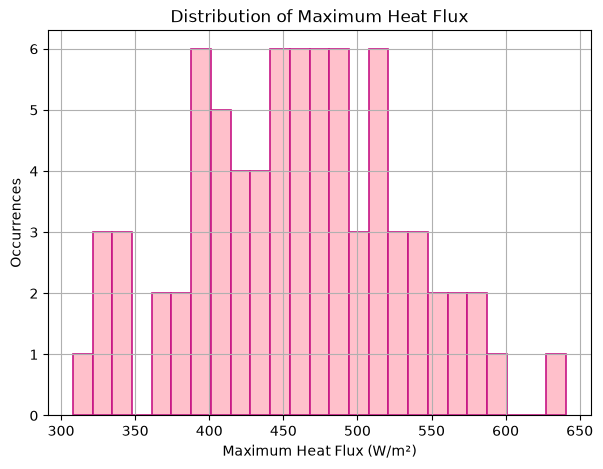

In [ ]:
# ============================================================
# PLOT 1: Maximum Heat Flux vs Occurrences
# ============================================================

plt.figure(figsize=(7,5))

plt.hist(
    success_df["max_total_heat_flux"],
    bins=25,
    color="#FFC2E9",
    edgecolor="#98174D",
    linewidth=1.2
)

plt.xlabel("Maximum Heat Flux (W/m²)")
plt.ylabel("Occurrences")
plt.title("Distribution of Maximum Heat Flux")

plt.grid(True)

plt.show()

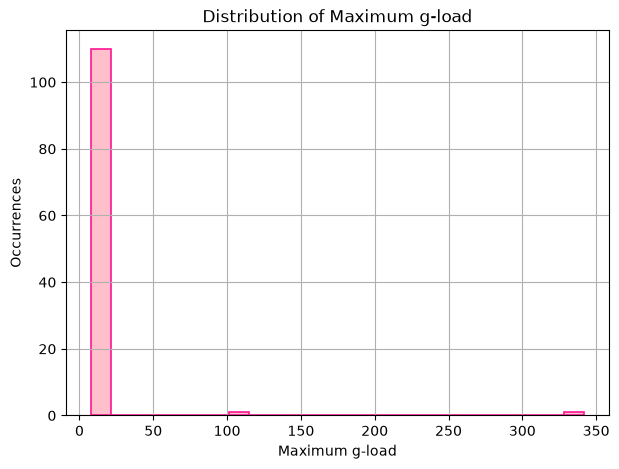

In [ ]:
# ============================================================
# PLOT 2: Maximum g-load vs Occurrences
# ============================================================

plt.figure(figsize=(7,5))

plt.hist(
    success_df["max_g_load"],
    bins=25,
    color="#FFC2E9",
    edgecolor="#98174D",
    linewidth=1.2
)

plt.xlabel("Maximum g-load")
plt.ylabel("Occurrences")
plt.title("Distribution of Maximum g-load")

plt.grid(True)

plt.show()

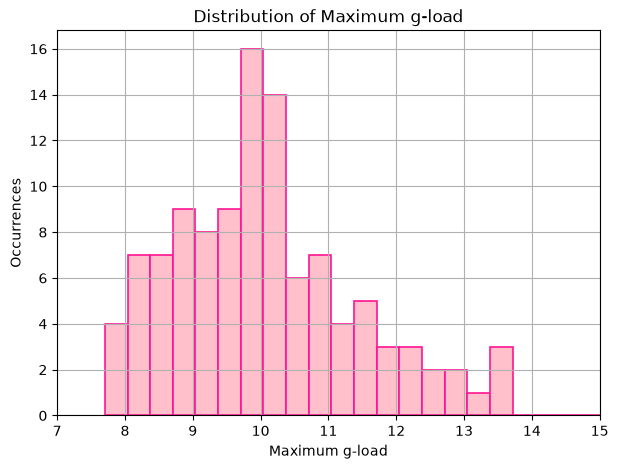

In [ ]:
# ============================================================
# PLOT 2: Maximum g-load vs Occurrences Ignoring Outliers (g-load < 15)
# ============================================================

plt.figure(figsize=(7,5))

plt.hist(
    success_df["max_g_load"],
    bins=1000,
    color="#FFC2E9",
    edgecolor="#98174D",
    linewidth=1.2
)

plt.xlabel("Maximum g-load")
plt.ylabel("Occurrences")
plt.title("Distribution of Maximum g-load")
plt.xlim(7,15)

plt.grid(True)

plt.show()

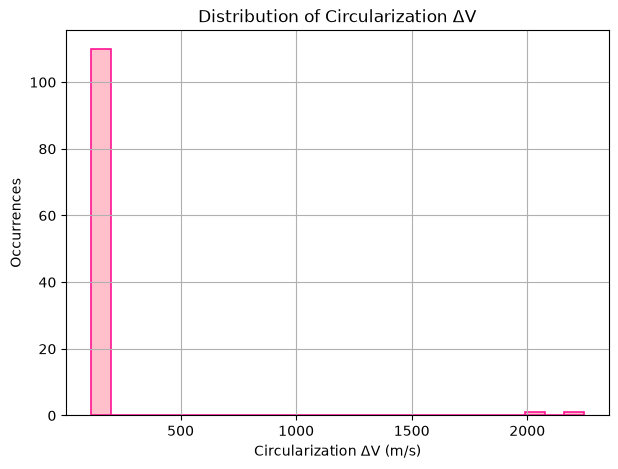

In [ ]:
# ============================================================
# PLOT 3: Delta-V vs Occurence
# ============================================================

plt.figure(figsize=(7,5))

plt.hist(
    success_df["delta_v"],
    bins=25,
    color="#FFC2E9",
    edgecolor="#98174D",
    linewidth=1.2
)

plt.xlabel("Circularization ΔV (m/s)")
plt.ylabel("Occurrences")
plt.title("Distribution of Circularization ΔV")

plt.grid(True)

plt.show()

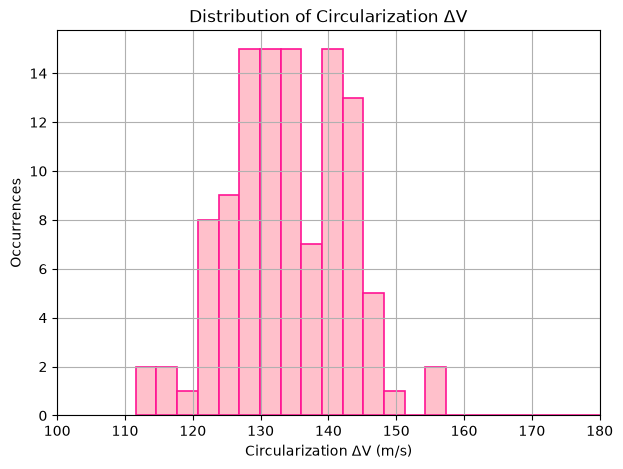

In [ ]:
# ============================================================
# PLOT 3: Delta-V vs Occurence Ignoring Outliers (Delta-V < 180 m/s)
# ============================================================

plt.figure(figsize=(7,5))

plt.hist(
    success_df["delta_v"],
    bins=700,
    color="#FFC2E9",
    edgecolor="#98174D",
    linewidth=1.2
)

plt.xlabel("Circularization ΔV (m/s)")
plt.ylabel("Occurrences")
plt.title("Distribution of Circularization ΔV")
plt.xlim(100, 180)

plt.grid(True)

plt.show()

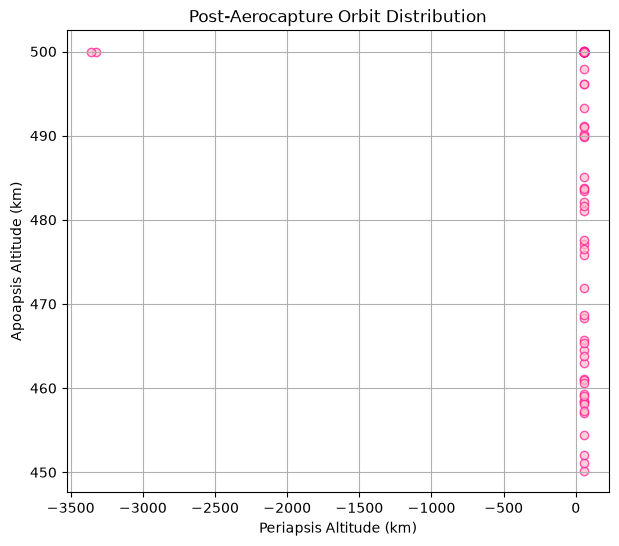

In [ ]:
# ============================================================
# PLOT 4: Apoapsis vs Periapsis
# ============================================================

plt.figure(figsize=(7,6))

plt.scatter(
    success_df["periapsis_altitude"]/1000,
    success_df["apoapsis_altitude"]/1000,
    color="#FFC2E9",
    edgecolor="#98174D",
    alpha=0.7
)

plt.xlabel("Periapsis Altitude (km)")
plt.ylabel("Apoapsis Altitude (km)")
plt.title("Post-Aerocapture Orbit Distribution")

plt.grid(True)

plt.show()